In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

file_path = r'D:\BaiduSyncdisk\引力波\2026太极科创计划\数据时频变化及可视化\LDC2_spritz_mbhb1_training_v1.h5'

with h5py.File(file_path, 'r') as f:
    
    print("文件里的数据集名称:", list(f.keys()))
    obs_data = f['obs']
    print("obs里的数据集名称:", list(obs_data.keys()))
    print("config里的数据集名称:", list(obs_data['config'].keys()))
    
    tdi = f['obs/tdi'][:]  
    print("TDI数据形状:", tdi.shape)
    print("TDI数据类型:", tdi.dtype)
    print("前几行数据:\n", tdi[:5])

   
    t = tdi['t'].flatten()  # 时间
    X = tdi['X'].flatten()  # X通道
    Y = tdi['Y'].flatten()  # Y通道  
    Z = tdi['Z'].flatten()  # Z通道

    X = np.nan_to_num(X, nan=0.0)
    Y = np.nan_to_num(Y, nan=0.0)
    Z = np.nan_to_num(Z, nan=0.0)


    
    print(f"观测时长: {(t[-1] - t[0]) / 86400:.1f} 天")
    print(f"X通道范围: {X.min():.2e} ~ {X.max():.2e}")
    
   
    dt = f['obs/config/dt'][()]
    print("\n时间间隔dt:", dt)
    dt_tdi = t[1]-t[0]
    print("\n时间间隔dt_tdi:", dt_tdi)
    







文件里的数据集名称: ['clean', 'header', 'instru', 'noisefree', 'obs', 'sky']
obs里的数据集名称: ['config', 'tdi']
config里的数据集名称: ['accnoise', 'accnoise_seed_1_over_f2_12', 'accnoise_seed_1_over_f2_13', 'accnoise_seed_1_over_f2_21', 'accnoise_seed_1_over_f2_23', 'accnoise_seed_1_over_f2_31', 'accnoise_seed_1_over_f2_32', 'accnoise_seed_1_over_f_12', 'accnoise_seed_1_over_f_13', 'accnoise_seed_1_over_f_21', 'accnoise_seed_1_over_f_23', 'accnoise_seed_1_over_f_31', 'accnoise_seed_1_over_f_32', 'backlink_ref_seed1_over_f_12', 'backlink_ref_seed1_over_f_13', 'backlink_ref_seed1_over_f_21', 'backlink_ref_seed1_over_f_23', 'backlink_ref_seed1_over_f_31', 'backlink_ref_seed1_over_f_32', 'backlink_ref_seed_f_12', 'backlink_ref_seed_f_13', 'backlink_ref_seed_f_21', 'backlink_ref_seed_f_23', 'backlink_ref_seed_f_31', 'backlink_ref_seed_f_32', 'backlink_tm_seed1_over_f_12', 'backlink_tm_seed1_over_f_13', 'backlink_tm_seed1_over_f_21', 'backlink_tm_seed1_over_f_23', 'backlink_tm_seed1_over_f_31', 'backlink_tm_seed

In [1]:
try:
    from WDMWaveletTransforms import wavelet_transforms
    
    print("✅ 导入成功！该文件包含以下函数/变量：")
    
    funcs = [name for name in dir(wavelet_transforms) if not name.startswith('_')]
    print(funcs)
    
except ImportError as e:
    print("❌ 导入失败，错误信息：", e)
    print("\n请检查路径是否正确。")
    print("提示：sys.path.append 的路径应该是包含 'WDMWaveletTransforms' 文件夹的那一层。")

using mkl fft
✅ 导入成功！该文件包含以下函数/变量：
['fft', 'inverse_wavelet_freq', 'inverse_wavelet_freq_helper_fast', 'inverse_wavelet_freq_time', 'inverse_wavelet_time', 'inverse_wavelet_time_helper_fast', 'np', 'phi_vec', 'phitilde_vec_norm', 'transform_wavelet_freq', 'transform_wavelet_freq_helper', 'transform_wavelet_freq_time', 'transform_wavelet_time', 'transform_wavelet_time_helper']


In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from WDMWaveletTransforms import transform_wavelet_time, transform_wavelet_freq_time

原始数据点数: 535680
截断后数据点数: 535552
变换网格大小: Nf=512, Nt=1046
正在进行小波变换，请稍候...
小波变换完成！
变换结果形状: (1046, 512)


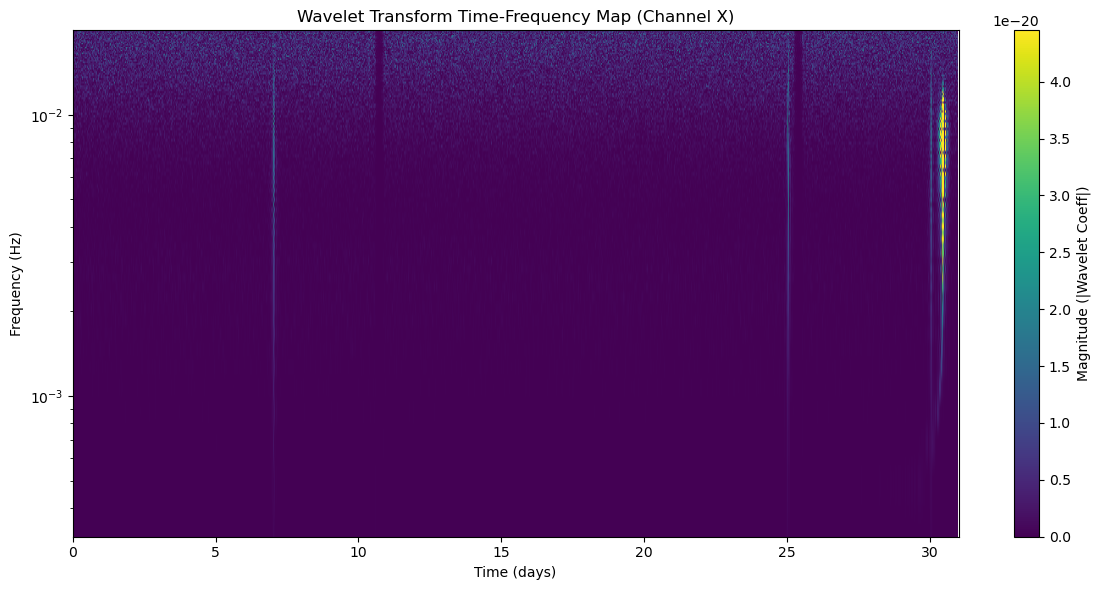

In [11]:
# Nf (频率网格数): 决定频率分辨率。Nf越大，频率分辨率越高，但时间分辨率越低。
# 这是一个“测不准关系”的体现，建议根据信号特征频率来调整。
Nf = 512  

# WDM变换要求总数据长度 ND = Nf * Nt，所以必须截取或填充数据使其长度能被Nf整除
ND_origin = len(X)
ND_new = (ND_origin // Nf) * Nf  # 计算最近的能被整除的长度

# 截取数据
data_X = X[-ND_new:]  # 截取
time_X = t[-ND_new:]  # 对应的时间轴也要截取

# 计算时间网格数 Nt
Nt = ND_new // Nf

print(f"原始数据点数: {ND_origin}")
print(f"截断后数据点数: {ND_new}")
print(f"变换网格大小: Nf={Nf}, Nt={Nt}")

print("正在进行小波变换，请稍候...")
wave_X = transform_wavelet_time(data_X, Nf, Nt)

print("小波变换完成！")
print("变换结果形状:", wave_X.shape)  


# 时间轴：转换为以天为单位
time_days = (time_X - time_X[0]) / 86400

# 频率轴：根据采样率和 Nf 计算真实频率
sampling_rate = 1.0 / dt_tdi  # 采样率
# 频率分辨率
freqs = np.linspace(0, sampling_rate/2, Nf) 
freqs[0] = 1e-10
plt.figure(figsize=(12, 6))

plt.imshow(np.abs(wave_X.T), aspect='auto', origin='lower',
           extent=[time_days[0], time_days[-1], freqs[0], freqs[-1]],
           cmap='viridis', vmin=0, vmax=np.percentile(np.abs(wave_X), 99)) 

plt.yscale('log')

plt.ylim(1.0*10**-3.5, 1.0*10**-1.7)
plt.colorbar(label='Magnitude (|Wavelet Coeff|)')
plt.xlabel('Time (days)')
plt.ylabel('Frequency (Hz)')
plt.title('Wavelet Transform Time-Frequency Map (Channel X)')
plt.tight_layout()
plt.show()



In [6]:
import torch_frft
print(torch_frft.__version__)


0.8.1


计算设备: cpu
输入数据形状: torch.Size([535680])
输入数据类型: torch.float32


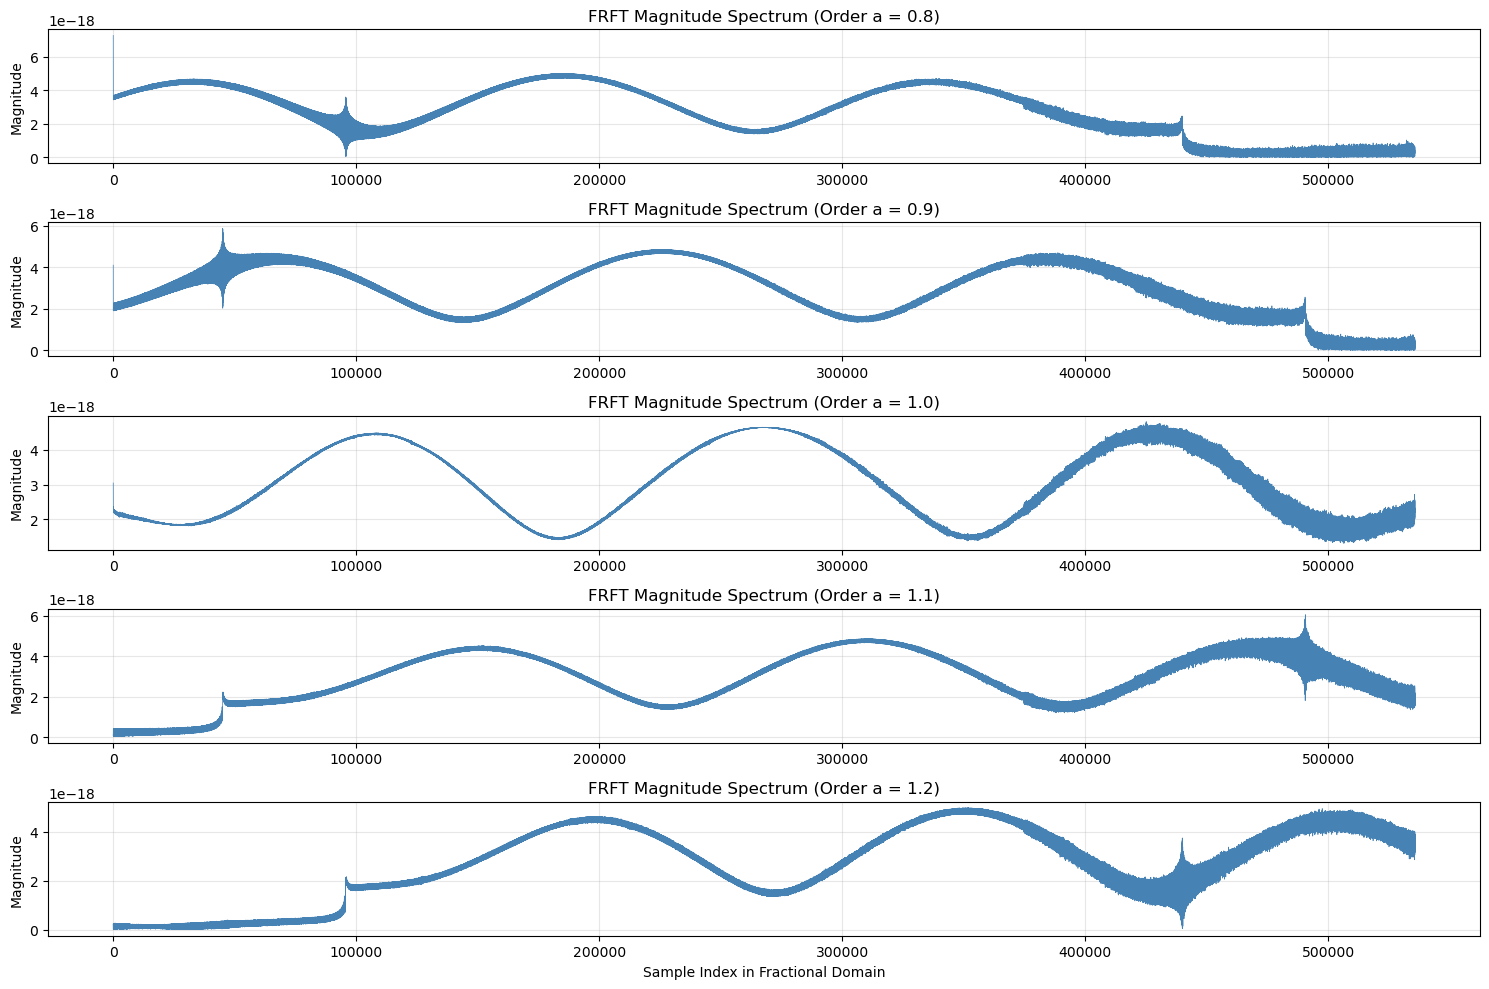


正在生成 FRFT 时频图（这可能需要一点时间）...


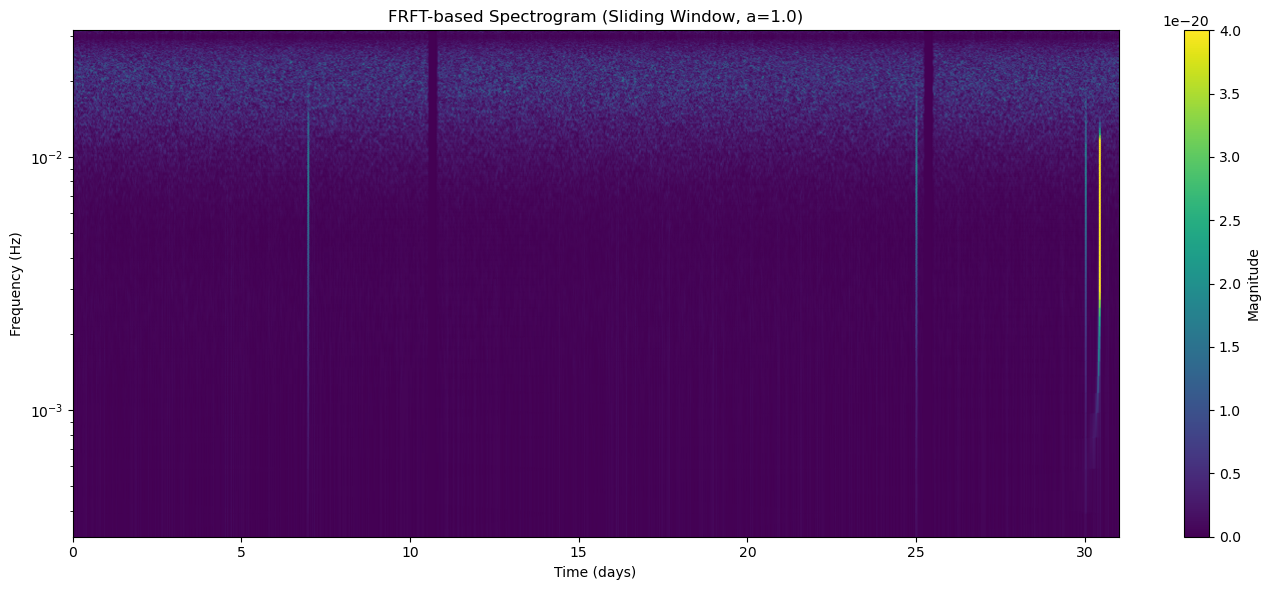

In [10]:
import torch
from torch_frft.frft_module import frft  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"计算设备: {device}")

# 转换为 PyTorch 张量
data_X = torch.from_numpy(X).float().to(device)

print(f"输入数据形状: {data_X.shape}")
print(f"输入数据类型: {data_X.dtype}")


orders_to_try = [0.8, 0.9, 1.0, 1.1, 1.2]

plt.figure(figsize=(15, 10))

for i, a_order in enumerate(orders_to_try):
    
    result_complex = frft(data_X, a_order)
    
    result_mag = torch.abs(result_complex)
    
    result_mag_np = result_mag.cpu().numpy()
    
    plt.subplot(len(orders_to_try), 1, i + 1)
    
    plt.plot(result_mag_np, color='steelblue', linewidth=0.5)
    
    plt.title(f'FRFT Magnitude Spectrum (Order a = {a_order})', fontsize=12)
    plt.ylabel('Magnitude')
    plt.grid(True, alpha=0.3)
    
    if i == len(orders_to_try) - 1:
        plt.xlabel('Sample Index in Fractional Domain')

plt.tight_layout()
plt.show()

print("\n正在生成 FRFT 时频图（这可能需要一点时间）...")


window_size = 1024  # 窗口大小
step_size = 512     # 步长
n_steps = (len(X) - window_size) // step_size + 1

# 存储结果的列表
frft_2d_result = []


for step in range(n_steps):
    start_idx = step * step_size
    end_idx = start_idx + window_size
    
    
    window_data = X[start_idx:end_idx]
    window_tensor = torch.from_numpy(window_data).float().to(device)
    
    res = frft(window_tensor, 1.0)
    mag = torch.abs(res).cpu().numpy()
    
    frft_2d_result.append(mag)


frft_2d_array = np.array(frft_2d_result).T

plt.figure(figsize=(14, 6))

# 计算时间轴
time_axis = np.linspace(t[0], t[-1], n_steps)
time_days = (time_axis - t[0]) / 86400

# 计算频率轴 (基于窗口大小和 dt_tdi)
freq_axis = np.fft.fftfreq(window_size, d=dt_tdi)
freq_axis = np.fft.fftshift(freq_axis)  # 将 0 频率移到中心
# 只取正频率部分
pos_freq_mask = freq_axis >= 0
freq_axis = freq_axis[pos_freq_mask]

# 对应的数据也只取正频率
frft_2d_plot = frft_2d_array[pos_freq_mask, :]

# 绘制热力图
# 注意：这里使用 pcolormesh 以便后续设置对数坐标
plt.pcolormesh(time_days, freq_axis, frft_2d_plot,
               shading='gouraud', cmap='viridis',
               vmin=0, vmax=np.percentile(frft_2d_plot, 99))
# --- 关键修改 2：设置频率轴为对数刻度 ---
plt.yscale('log')
# 设置 y 轴显示范围，从极小值到最大频率
plt.ylim(1.0*10**-3.5, 1.0*10**-1.5)
plt.colorbar(label='Magnitude')
plt.xlabel('Time (days)')
plt.ylabel('Frequency (Hz)')
plt.title('FRFT-based Spectrogram (Sliding Window, a=1.0)')
plt.tight_layout()
plt.show()
